In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load saved data
df = pd.read_csv("../data/prices_clean.csv", index_col="Date", parse_dates=True)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.tail()

Shape: (1254, 5)
Columns: ['Gold', 'SP500', 'BCA', 'Telkom', 'Bitcoin']


,Gold,SP500,BCA,Telkom,Bitcoin
Date,,,,,
2025-12-23,8025.0,413.640015,686.086304,3470.0,87414.000000
2025-12-24,8025.0,411.929993,688.499695,3460.0,87611.960938
2025-12-26,8025.0,416.739990,688.429871,3460.0,87301.429688
2025-12-29,8025.0,398.600006,685.976562,3490.0,87138.140625
2025-12-30,8075.0,398.890015,685.138916,3480.0,88430.132812


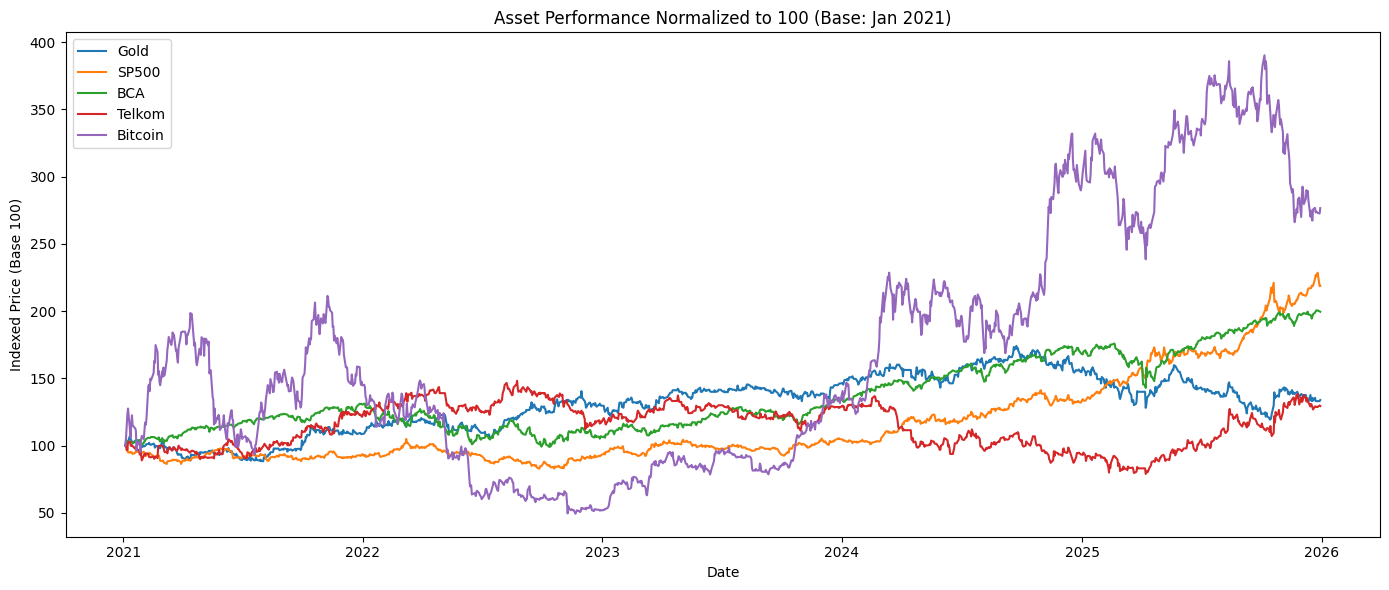

In [3]:
normalized = df / df.iloc[0] * 100

plt.figure(figsize=(14, 6))

for column in normalized.columns:
    plt.plot(normalized.index, normalized[column], label=column)

plt.title("Asset Performance Normalized to 100 (Base: Jan 2021)")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Base 100)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/chart_normalized_performance.png", dpi=150)
plt.show()

In [4]:
returns = df.pct_change().dropna()

print("Daily Returns - Summary Statistics:")
print(returns.describe().round(4))

Daily Returns - Summary Statistics:
            Gold      SP500        BCA     Telkom    Bitcoin
count  1253.0000  1253.0000  1253.0000  1253.0000  1253.0000
mean      0.0003     0.0007     0.0006     0.0004     0.0015
std       0.0143     0.0098     0.0108     0.0178     0.0370
min      -0.0853    -0.0643    -0.0585    -0.0671    -0.2268
25%      -0.0081    -0.0047    -0.0045    -0.0089    -0.0174
50%       0.0000     0.0006     0.0008     0.0000     0.0004
75%       0.0072     0.0062     0.0063     0.0096     0.0198
max       0.0762     0.0370     0.1050     0.1156     0.2111


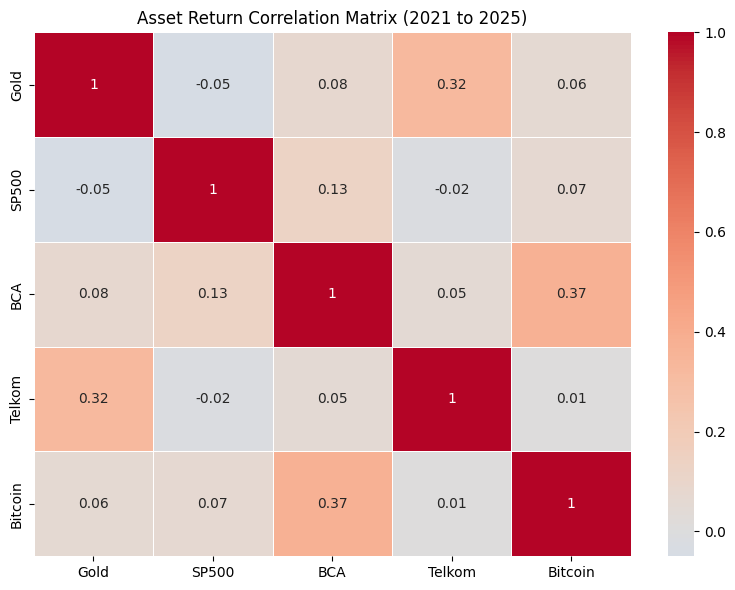

         Gold  SP500   BCA  Telkom  Bitcoin
Gold     1.00  -0.05  0.08    0.32     0.06
SP500   -0.05   1.00  0.13   -0.02     0.07
BCA      0.08   0.13  1.00    0.05     0.37
Telkom   0.32  -0.02  0.05    1.00     0.01
Bitcoin  0.06   0.07  0.37    0.01     1.00


In [5]:
correlation = returns.corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Asset Return Correlation Matrix (2021 to 2025)")
plt.tight_layout()
plt.savefig("../data/chart_correlation_heatmap.png", dpi=150)
plt.show()

print(correlation)

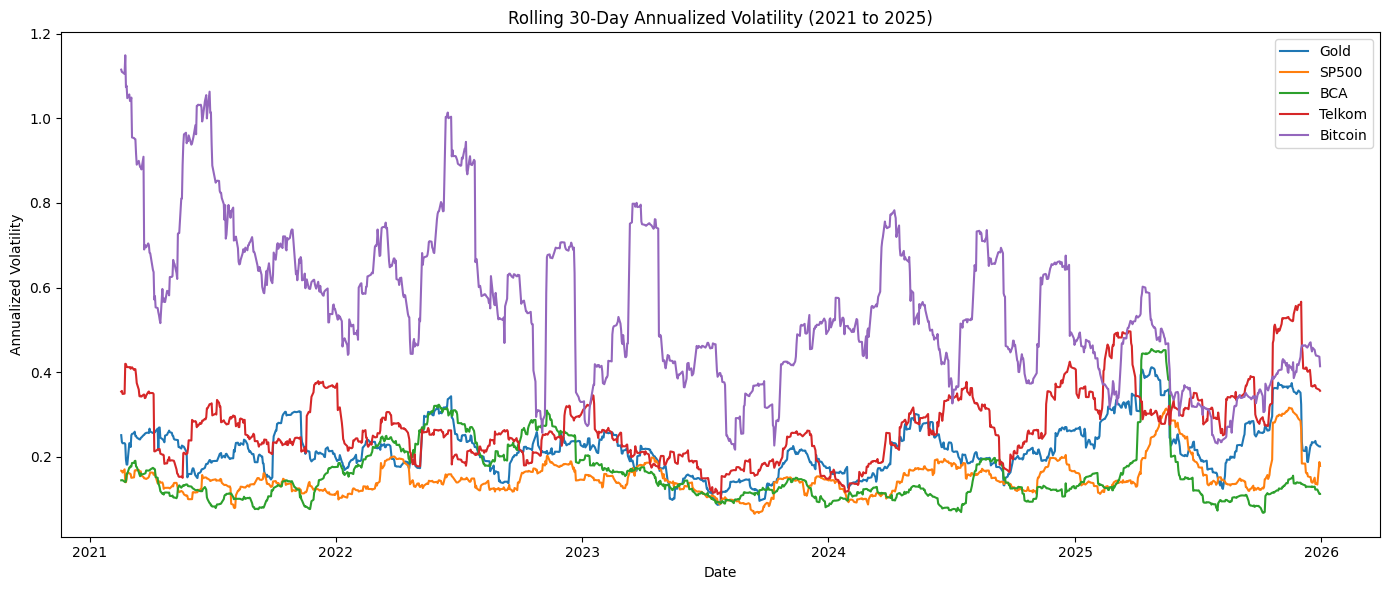

In [6]:
rolling_vol = returns.rolling(window=30).std() * (252 ** 0.5)

plt.figure(figsize=(14, 6))

for column in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[column], label=column)

plt.title("Rolling 30-Day Annualized Volatility (2021 to 2025)")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.tight_layout()
plt.savefig("../data/chart_rolling_volatility.png", dpi=150)
plt.show()

In [7]:
# Annualized return and volatility
annualized_return = returns.mean() * 252
annualized_vol = returns.std() * (252 ** 0.5)

# Sharpe Ratio (using 4% as risk free rate, approximate Indonesian SBI rate)
risk_free_rate = 0.04
sharpe = (annualized_return - risk_free_rate) / annualized_vol

# Max Drawdown
def max_drawdown(price_series):
    rolling_max = price_series.cummax()
    drawdown = (price_series - rolling_max) / rolling_max
    return drawdown.min()

max_dd = df.apply(max_drawdown)

# Compile results
metrics = pd.DataFrame({
    "Annualized Return": annualized_return.round(4),
    "Annualized Volatility": annualized_vol.round(4),
    "Sharpe Ratio": sharpe.round(4),
    "Max Drawdown": max_dd.round(4)
})

print("Risk and Return Metrics (2021 to 2025)")
print(metrics)

metrics.to_csv("../data/metrics_summary.csv")
print("Saved to data/metrics_summary.csv")

Risk and Return Metrics (2021 to 2025)
         Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown
Gold                0.0843                 0.2263        0.1958       -0.3141
SP500               0.1697                 0.1562        0.8304       -0.2103
BCA                 0.1536                 0.1711        0.6638       -0.2450
Telkom              0.0918                 0.2829        0.1830       -0.4669
Bitcoin             0.3773                 0.5874        0.5742       -0.7663
Saved to data/metrics_summary.csv


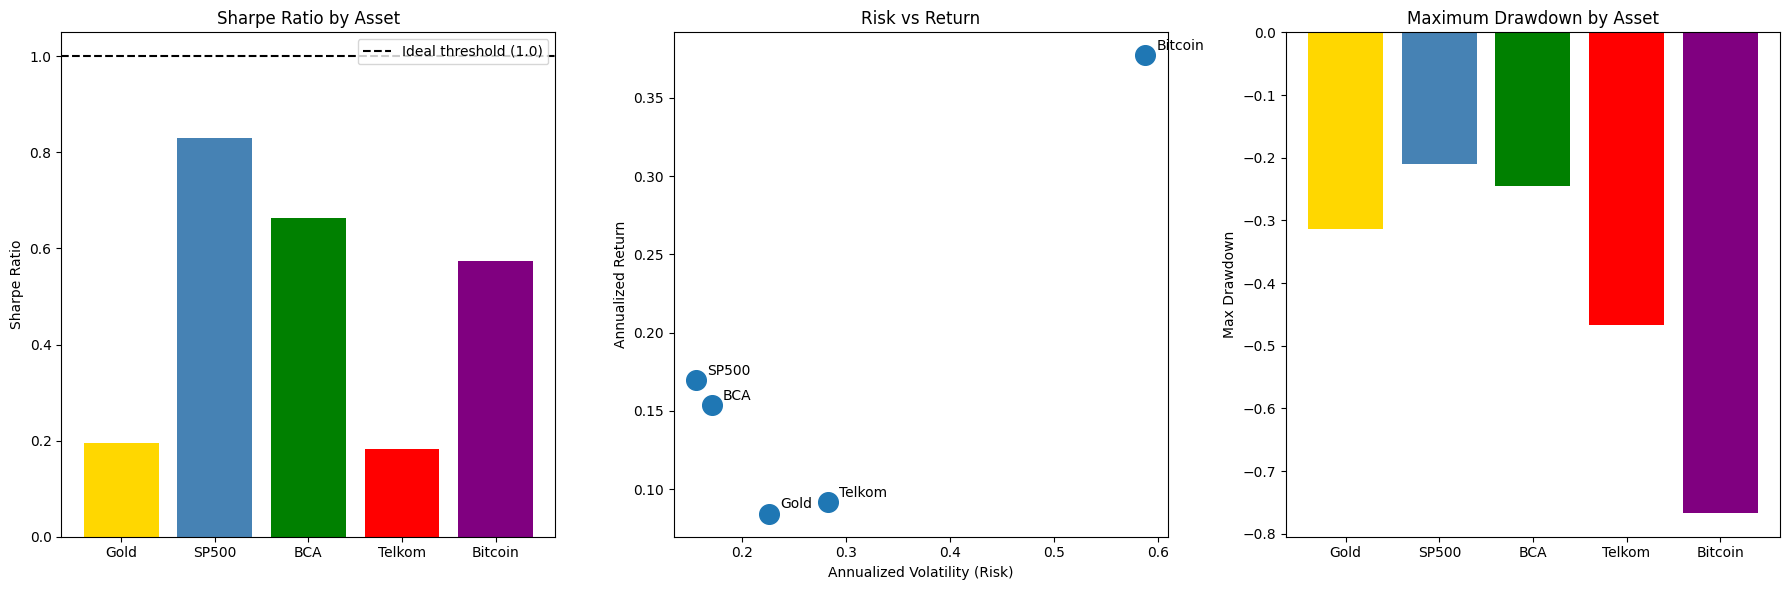

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 - Sharpe Ratio
axes[0].bar(metrics.index, metrics["Sharpe Ratio"], color=["gold", "steelblue", "green", "red", "purple"])
axes[0].set_title("Sharpe Ratio by Asset")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].axhline(y=1.0, color="black", linestyle="dashed", label="Ideal threshold (1.0)")
axes[0].legend()

# Chart 2 - Risk vs Return scatter
axes[1].scatter(
    metrics["Annualized Volatility"],
    metrics["Annualized Return"],
    s=200
)
for asset in metrics.index:
    axes[1].annotate(
        asset,
        (metrics.loc[asset, "Annualized Volatility"],
         metrics.loc[asset, "Annualized Return"]),
        textcoords="offset points",
        xytext=(8, 4)
    )
axes[1].set_title("Risk vs Return")
axes[1].set_xlabel("Annualized Volatility (Risk)")
axes[1].set_ylabel("Annualized Return")

# Chart 3 - Max Drawdown
axes[2].bar(metrics.index, metrics["Max Drawdown"], color=["gold", "steelblue", "green", "red", "purple"])
axes[2].set_title("Maximum Drawdown by Asset")
axes[2].set_ylabel("Max Drawdown")

plt.tight_layout()
plt.savefig("../data/chart_metrics_summary.png", dpi=150)
plt.show()